# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [1]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [2]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [41]:
now = Time.now()
print(f"ISO UTC: {now.utc.iso}")
print(f"IST: {now.to_datetime(IITK_TIMEZONE)}")



ISO UTC: 2026-09-05 17:25:54.947
IST: 2026-09-05 22:55:54.947055+05:30


Answer: There will finite time diffrence beeen the first and the second call, thas why described time might not be same.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [183]:
GTC_height = 2396 * u.m

wavelength = 600 * u.nm

coordinate_uncertainty = 5 * u.mas

Cadence = 10 * u.min

radio_frequency = 1.4 * u.GHz

print(f"GTC_height: {GTC_height, GTC_height.to(u.km)}")
print(f"wavelength: {wavelength, wavelength.to(u.THz, equivalencies = u.spectral())}")
print(f"radio_frequency: {radio_frequency, radio_frequency.to(u.cm, equivalencies = u.spectral())}")
print(f"coordinate_uncertainty: {coordinate_uncertainty, coordinate_uncertainty.to(u.arcsec)}")
print(f"Cadence: {Cadence, Cadence.to(u.h)}")


GTC_height: (<Quantity 2396. m>, <Quantity 2.396 km>)
wavelength: (<Quantity 600. nm>, <Quantity 499.65409667 THz>)
radio_frequency: (<Quantity 1.4 GHz>, <Quantity 21.413747 cm>)
coordinate_uncertainty: (<Quantity 5. mas>, <Quantity 0.005 arcsec>)
Cadence: (<Quantity 10. min>, <Quantity 0.16666667 h>)


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [184]:
planning_start = Time(START_UTC, scale="utc")
print(f"planning_start_utc_iso: {planning_start.utc.iso}")
print(f"planning_start_jd: {planning_start.jd}")
print(f"planning_start_mjd: {planning_start.mjd}")
IST_1 = planning_start.to_datetime(IITK_TIMEZONE)
print(f"IST_1: {IST_1}")
time_arithmetic = planning_start + 2.25 * u.hour
print(f"time_arithmetic_utc: {time_arithmetic.utc}")
IST_2 = time_arithmetic.to_datetime(IITK_TIMEZONE)
print(f"IST_2: {IST_2}")


original_ist = Time(IST_1)

difference = abs((original_ist - planning_start).to_value(u.microsecond))

print(f"difference: {difference * u.microsecond} ")

if difference < 1e-6:
    print("True")
else:
    print("False")

planning_start_utc_iso: 2026-08-30 12:00:00.000
planning_start_jd: 2461283.0
planning_start_mjd: 61282.5
IST_1: 2026-08-30 17:30:00+05:30
time_arithmetic_utc: 2026-08-30T14:15:00.000
IST_2: 2026-08-30 19:45:00+05:30
difference: 0.0 us 
True


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [186]:
FRB_RA = Angle(FRB_RA_J2000)
FRB_DEC = Angle(FRB_DEC_J2000)

frb_icrs = SkyCoord(ra=FRB_RA , dec=FRB_DEC, frame="icrs")
print(f"frb_icrs: {frb_icrs}")
print(f"frb_icrs_ra: {frb_icrs.ra.deg * u.deg}")
print(f"frb_icrs_dec: {frb_icrs.dec.deg * u.deg}")
print(f"FRB_RA in sexagesimal: {frb_icrs.ra.to_string(unit=u.hour, sep=":", pad = True, alwayssign = True, precision = 8) }") 
print(f"FRB_DEC in sexagesimal: {frb_icrs.dec.to_string(unit=u.deg, sep=":", pad = True, alwayssign = True, precision = 8) }")

ra_ref = 347.2704120833
dec_ref = 48.7066410556

RA_difference = abs(frb_icrs.ra.deg - ra_ref )
DEC_difference = abs(frb_icrs.dec.deg - dec_ref)

print(f"RA_difference: {RA_difference * u.deg}")
print(f"DEC_difference: {DEC_difference * u.deg}") 

if RA_difference < 1e-8:
    print("RA is within 1e-8")
else:
    print("RA is not within 1e-8")
    
if DEC_difference < 1e-8:
    print("DEC is within 1e-8")
else:
    print("DEC is not within 1e-8")




frb_icrs: <SkyCoord (ICRS): (ra, dec) in deg
    (347.27041208, 48.70664106)>
frb_icrs_ra: 347.27041208333327 deg
frb_icrs_dec: 48.70664105555556 deg
FRB_RA in sexagesimal: +23:09:04.89890000
FRB_DEC in sexagesimal: +48:42:23.90780000
RA_difference: 3.325340003357269e-11 deg
DEC_difference: 4.4444448121794267e-11 deg
RA is within 1e-8
DEC is within 1e-8


Answer: AS celestial coordinate system is defined relative to earths rotation, the RA measures the position along the celestial equator and one complete rotation of earth will take 24H so astronomrs use hour, minute and seconds.While for declination measures the angular distance to north or south of celestial equaor, so degree, acminute and arcsecond is used commonly.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [187]:
frb_galactic = frb_icrs.transform_to("galactic")
print(f"Galactic longitude: {frb_galactic.l}, Galactic latitude: {frb_galactic.b}")

frb_back_icrs = frb_galactic.transform_to("icrs")

round_trip_separation_ra = abs(frb_back_icrs.ra - frb_icrs.ra).to_value(u.uas)
round_trip_separation_dec = abs(frb_back_icrs.dec - frb_icrs.dec).to_value(u.uas)

print(f"round_trip_separation_ra: {round_trip_separation_ra } uas ")
print(f"round_trip_separation_dec: {round_trip_separation_dec } uas ")

 

Galactic longitude: 106.06496077332801 deg, Galactic latitude: -10.784176285402495 deg
round_trip_separation_ra: 0.0 uas 
round_trip_separation_dec: 0.00025579538487363607 uas 


The tiny non-zero residual is due to the floting point error. The programm takes several steps to calculate thes valuse and at every step it loses a small amount of bits while calculations.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [175]:
frb_ecliptic = frb_icrs.transform_to(BarycentricTrueEcliptic(equinox="J2000"))
print(f"ecliptic longitude: {frb_ecliptic.lon.deg * u.deg} , ecliptic latitude: {frb_ecliptic.lat.deg * u.deg} ")


assert (0 * u.deg <= frb_ecliptic.lon) and (frb_ecliptic.lon < 360 * u.deg)
assert (-90 * u.deg <= frb_ecliptic.lat) and (frb_ecliptic.lat <= 90 * u.deg)
print("Range verified.")

frb_back_icrs = frb_ecliptic.transform_to("icrs")

round_trip_difference_ra = abs(frb_back_icrs.ra - frb_icrs.ra).to_value(u.uas)
round_trip_difference_dec = abs(frb_back_icrs.dec - frb_icrs.dec).to_value(u.uas)

print(f"Round-trip_RA_difference : {round_trip_difference_ra} uas")
print(f"Round-trip_DEC_difference: {round_trip_difference_dec} uas")




ecliptic longitude: 14.411187650340095 deg , ecliptic latitude: 48.34695843744783 deg 
Range verified.
Round-trip_RA_difference : 0.00020463630789890885 uas
Round-trip_DEC_difference: 2.5579538487363607e-05 uas


Answer: Ecliptic plane is the plane formed by the earths orbit around the sun.
Whereas $\beta$ says how far the object is above or below the ecliptic plane.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [200]:
earlier_position = SkyCoord(ra="23h09m04.9s", dec="+48d42m25.4s", frame="icrs")

ra1 = np.longdouble(frb_icrs.ra.to_value(u.rad))
dec1 = np.longdouble(frb_icrs.dec.to_value(u.rad))
ra2 = np.longdouble(earlier_position.ra.to_value(u.rad))
dec2 = np.longdouble(earlier_position.dec.to_value(u.rad))

cos_theta = (np.sin(dec1) * np.sin(dec2) + np.cos(dec1) * np.cos(dec2) * np.cos(ra2 - ra1))

cos_theta = np.clip(cos_theta, -1.0, 1.0)
delta_theta_rad = np.arccos(cos_theta)

delta_theta_arcsec = ((delta_theta_rad * u.rad).to(u.arcsec))
delta_theta_mas = (delta_theta_rad * u.rad).to(u.mas)

print(f"calculated_separation (arcsec): {delta_theta_arcsec}")
print(f"calculated_separation (mas): {delta_theta_mas}")

astropy_separation = (frb_icrs.separation(earlier_position).to(u.arcsec))
print(f"astropy_separation: {astropy_separation}")
difference = abs(astropy_separation - delta_theta_arcsec).to(u.arcsec)

print(f"Difference from Astropy separation: {difference}")

if difference < 1e-6 * u.arcsec: 
    print("Agreement verified.") 
elif difference < 1e-5 * u.arcsec: 
    print("Agreement is within numerical precision.") 


calculated_separation (arcsec): 1.4922374490540065 arcsec
calculated_separation (mas): 1492.2374490540062 mas
astropy_separation: 1.492239726203449 arcsec
Difference from Astropy separation: 2.277149442564408e-06 arcsec
Agreement is within numerical precision.


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [189]:
gtc_location = EarthLocation.from_geodetic(lon=GTC_LONGITUDE_DEG * u.deg, lat=GTC_LATITUDE_DEG * u.deg, height=GTC_HEIGHT_M * u.m,)

lon, lat, height = gtc_location.to_geodetic()
print(f"GTC longitude: {lon}")
print(f"GTC latitude: {lat}")
print(f"GTC height: {height}")

GTC longitude: -17.88900000000001 deg
GTC latitude: 28.758 deg
GTC height: 2395.9999999997463 m


Answer: As GTC is in the west of the prime meridian so the longitude is negative.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [190]:
gtc_observer = Observer(location=gtc_location, name="GTC")
time_q9 = Time("2026-08-31T00:00:00", scale="utc")
lst_q9 = gtc_observer.local_sidereal_time(time_q9, kind="apparent")
hour_angle_q9 = (lst_q9 - frb_icrs.ra).wrap_at(12 * u.hourangle)

print(f"UTC: {format_utc(time_q9)}")
print(f"IST: {format_iitk(time_q9)}")
print(f"LST: {lst_q9.to_string(unit=u.hour, sep=':', pad=True, precision=2)}")
print(f"Hour angle: {hour_angle_q9.to_string(unit=u.hour, sep=':', pad=True, alwayssign=True, precision=2)}")

if hour_angle_q9 < 0 * u.hourangle:
    print("The target is east of the meridian.")
elif hour_angle_q9 > 0 * u.hourangle:
    print("The target is west of the meridian.")
else:
    print("The target is transiting.")

UTC: 2026-08-31 00:00:00 UTC
IST: 2026-08-31 05:30:00 IST
LST: 21:25:12.21
Hour angle: -01:43:52.69
The target is east of the meridian.


Answer: A negative hour angle means the source has not yet crossed the local meridian.

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [191]:
lst_all = gtc_observer.local_sidereal_time(times, kind="apparent")
hour_angle_all = (lst_all - frb_icrs.ra).wrap_at(12 * u.hourangle)
transit_index = int(np.argmin(np.abs(hour_angle_all.to_value(u.hourangle))))
transit_time = times[transit_index]
print(f"Sample index: {transit_index}")
print(f"UTC: {format_utc(transit_time)}")
print(f"IST: {format_iitk(transit_time)}")
print(f"LST: {lst_all[transit_index].to_string(unit=u.hour, sep=':', pad=True, precision=2)}")
print(f"Hour angle: {hour_angle_all[transit_index].to_string(unit=u.hour, sep=':', pad=True, alwayssign=True, precision=2)}")

Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
LST: 23:05:28.63
Hour angle: -00:03:36.27


Answer:  It is only a sampled approximation because the grid contains one point every 10 minutes, whereas, the true transit can occur between two samples.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [201]:
gtc_latitude = GTC_LATITUDE_DEG * u.deg
analytic_transit_altitude = 90 * u.deg - abs(gtc_latitude - frb_icrs.dec)
analytic_zenith_distance = 90 * u.deg - analytic_transit_altitude
print(f"Analytic transit altitude: {analytic_transit_altitude}")
print(f"Analytic zenith distance: {analytic_zenith_distance}")

frb_gtc_altaz = frb_icrs.transform_to(AltAz(obstime=times, location=gtc_location, pressure=0 * u.hPa))
max_altitude_index = int(np.argmax(frb_gtc_altaz.alt.to_value(u.deg)))
max_altitude = frb_gtc_altaz.alt[max_altitude_index]
max_zenith_distance = 90 * u.deg - max_altitude
print(f"Largest sampled altitude: {max_altitude}")
print(f"Sampled zenith distance: {max_zenith_distance}")
print(f"Altitude difference: {(max_altitude - analytic_transit_altitude).to(u.arcsec)}")

Analytic transit altitude: 70.05135894444444 deg
Analytic zenith distance: 19.948641055555555 deg
Largest sampled altitude: 69.88391103909186 deg
Sampled zenith distance: 20.116088960908144 deg
Altitude difference: -602.8124592693189 arcsec


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [202]:
indices_q12 = [transit_index - 12, transit_index, transit_index + 12]
phi = GTC_LATITUDE_DEG * u.deg
delta = frb_icrs.dec

for index in indices_q12:
    sample_time = times[index]
    H = hour_angle_all[index]
    H_rad = H.to_value(u.rad)
    phi_rad = phi.to_value(u.rad)
    delta_rad = delta.to_value(u.rad)
    sin_h = (np.sin(phi_rad) * np.sin(delta_rad) + np.cos(phi_rad) * np.cos(delta_rad) * np.cos(H_rad))
    calculated_altitude = np.arcsin(np.clip(sin_h, -1, 1)) * u.rad
    astropy_altitude = frb_gtc_altaz.alt[index]
    difference = (calculated_altitude - astropy_altitude).to(u.arcsec)
    print(f"UTC: {format_utc(sample_time)}")
    print(f"IST: {format_iitk(sample_time)}")
    print(f"Hour angle: {H.to_string(unit=u.hour, sep=':', pad=True, alwayssign=True, precision=2)}")
    print(f"Calculated altitude: {calculated_altitude.to(u.deg)}")
    print(f"Astropy altitude: {astropy_altitude.to(u.deg)}")
    print(f"Difference: {difference}")
    print()

UTC: 2026-08-30 23:40:00 UTC
IST: 2026-08-31 05:10:00 IST
Hour angle: -02:03:55.98
Calculated altitude: 59.031945606325905 deg
Astropy altitude: 58.78157159780014 deg
Difference: 901.3464306927707 arcsec

UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Hour angle: -00:03:36.27
Calculated altitude: 70.03934732667065 deg
Astropy altitude: 69.88391103909186 deg
Difference: 559.5706352836971 arcsec

UTC: 2026-08-31 03:40:00 UTC
IST: 2026-08-31 09:10:00 IST
Hour angle: +01:56:43.45
Calculated altitude: 60.063046770400355 deg
Astropy altitude: 60.16261143106733 deg
Difference: -358.43277840113257 arcsec



## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [206]:
hmin = MIN_TARGET_ALTITUDE_DEG * u.deg
phi_rad = (GTC_LATITUDE_DEG * u.deg).to_value(u.rad)
delta_rad = frb_icrs.dec.to_value(u.rad)
hmin_rad = hmin.to_value(u.rad)

cos_H0 = ((np.sin(hmin_rad) - np.sin(phi_rad) * np.sin(delta_rad)) / (np.cos(phi_rad) * np.cos(delta_rad)))
cos_H0 = np.clip(cos_H0, -1, 1)
H0 = np.arccos(cos_H0) * u.rad
H0_degrees = H0.to(u.deg)
H0_sidereal_hours = H0.to_value(u.deg) / 15
above20_hours = 2 * H0_sidereal_hours
above20_samples = int(np.count_nonzero(frb_gtc_altaz.alt >= hmin))

print(f"H0: {H0_degrees}")
print(f"H0: {H0_sidereal_hours} sidereal hour")
print(f"estimated interval 2H0: {above20_hours} hour")
print(f"grid samples above 20 deg: {above20_samples}")

H0: 91.92747700350239 deg
H0: 6.128498466900159 sidereal hour
estimated interval 2H0: 12.256996933800318 hour
grid samples above 20 deg: 74


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [207]:
target_airmass = np.asarray(frb_gtc_altaz.secz.to_value(u.dimensionless_unscaled), dtype=float)
target_altitude = frb_gtc_altaz.alt.to_value(u.deg)
invalid = (target_altitude <= 0) | (~np.isfinite(target_airmass)) | (target_airmass < 1)
target_airmass[invalid] = np.nan

best_index = int(np.nanargmin(target_airmass))
print(f"Finite airmass range: {np.nanmin(target_airmass):.6f} to {np.nanmax(target_airmass):.6f}")
print(f"Best airmass: {target_airmass[best_index]:.6f}")
print(f"Best airmass UTC: {format_utc(times[best_index])}")
print(f"Best airmass IST: {format_iitk(times[best_index])}")
print(f"Samples with 1 <= X <= 2.5: {np.count_nonzero(np.isfinite(target_airmass) & (target_airmass >= 1) & (target_airmass <= MAX_AIRMASS))}")

Finite airmass range: 1.064965 to 55.338396
Best airmass: 1.064965
Best airmass UTC: 2026-08-31 01:40:00 UTC
Best airmass IST: 2026-08-31 07:10:00 IST
Samples with 1 <= X <= 2.5: 68


Answer: Airmass is a measure of atmospheric path length with respect to the zenith. Values below 1 or non-finite values are not physical observing airmasses. So, below-horizon positions should not be interpreted as usable lines of sight.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [208]:
with solar_system_ephemeris.set("builtin"):
    sun = get_sun(times)
    moon = get_body("moon", times, location=gtc_location)

sun_altaz = sun.transform_to(AltAz(obstime=times, location=gtc_location))
moon_altaz = moon.transform_to(AltAz(obstime=times, location=gtc_location))

sun_altitude = sun_altaz.alt.to_value(u.deg)
moon_altitude = moon_altaz.alt.to_value(u.deg)
moon_airmass = np.asarray(moon_altaz.secz.to_value(u.dimensionless_unscaled), dtype=float)
moon_airmass[(moon_altitude <= 0) | (~np.isfinite(moon_airmass)) | (moon_airmass < 1) | (moon_airmass > 3)] = np.nan
moon_separation = frb_icrs.separation(moon).to_value(u.deg)

elongation = sun.separation(moon).to_value(u.rad)
illuminated_fraction = (1 - np.cos(elongation)) / 2

moon_label = np.full(len(times), "Unknown", dtype=object)
finite = np.isfinite(moon_altitude) & np.isfinite(moon_separation) & np.isfinite(illuminated_fraction)
moon_label[finite] = "Gray"
bright = finite & (((illuminated_fraction >= 0.70) & (moon_altitude > 10)) | (moon_separation <= 45))
moon_label[bright] = "Bright"
dark = finite & ((moon_altitude < 0) | ((moon_separation >= 90) & (illuminated_fraction <= 0.25)))
moon_label[dark] = "Dark"

print("Sun altitude, Moon altitude, Moon airmass, Moon-target separation, illuminated fraction, label")
for i in range(len(times)):
    print(f"{format_utc(times[i])}, {sun_altitude[i]:8.3f} deg, {moon_altitude[i]:8.3f} deg, {moon_airmass[i]:8.3f}, {moon_separation[i]:8.3f} deg, {illuminated_fraction[i]:.3f}, {moon_label[i]}")
print(f"Transit Moon label: {moon_label[transit_index]}")

Sun altitude, Moon altitude, Moon airmass, Moon-target separation, illuminated fraction, label
2026-08-30 12:00:00 UTC,   63.876 deg,  -37.679 deg,      nan,   58.346 deg, 0.941, Dark
2026-08-30 12:10:00 UTC,   65.333 deg,  -39.408 deg,      nan,   58.342 deg, 0.940, Dark
2026-08-30 12:20:00 UTC,   66.646 deg,  -41.091 deg,      nan,   58.339 deg, 0.940, Dark
2026-08-30 12:30:00 UTC,   67.787 deg,  -42.723 deg,      nan,   58.336 deg, 0.940, Dark
2026-08-30 12:40:00 UTC,   68.729 deg,  -44.297 deg,      nan,   58.333 deg, 0.939, Dark
2026-08-30 12:50:00 UTC,   69.445 deg,  -45.808 deg,      nan,   58.329 deg, 0.939, Dark
2026-08-30 13:00:00 UTC,   69.909 deg,  -47.250 deg,      nan,   58.326 deg, 0.939, Dark
2026-08-30 13:10:00 UTC,   70.105 deg,  -48.614 deg,      nan,   58.323 deg, 0.938, Dark
2026-08-30 13:20:00 UTC,   70.024 deg,  -49.892 deg,      nan,   58.319 deg, 0.938, Dark
2026-08-30 13:30:00 UTC,   69.670 deg,  -51.077 deg,      nan,   58.316 deg, 0.937, Dark
2026-08-30 13:4

## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [211]:
def visibility(altitude, airmass, sun_altitude, moon_separation):
    altitude = np.asarray(altitude)
    airmass = np.asarray(airmass)
    sun_altitude = np.asarray(sun_altitude)
    moon_separation = np.asarray(moon_separation)

    if altitude.ndim != 1 or airmass.ndim != 1 or sun_altitude.ndim != 1 or moon_separation.ndim != 1:
        raise ValueError("All inputs must be one-dimensional arrays.")
    if not (len(altitude) == len(airmass) == len(sun_altitude) == len(moon_separation)):
        raise ValueError("All inputs must have equal length.")

    altitude_ok = (altitude >= MIN_TARGET_ALTITUDE_DEG)
    airmass_ok = (np.isfinite(airmass) & (airmass >= 1) & (airmass <= MAX_AIRMASS))
    sun_ok = (sun_altitude <= MAX_SUN_ALTITUDE_DEG)
    moon_ok = (moon_separation >= MIN_MOON_SEPARATION_DEG)
    state = altitude_ok & airmass_ok & sun_ok & moon_ok

    print(f"Altitude condition count: {np.count_nonzero(altitude_ok)}")
    print(f"Airmass condition count: {np.count_nonzero(airmass_ok)}")
    print(f"Sun condition count: {np.count_nonzero(sun_ok)}")
    print(f"Moon separation condition count: {np.count_nonzero(moon_ok)}")
    print(f"Combined count: {np.count_nonzero(state)}")
    print(f"Overall yes/no: {bool(np.any(state))}")
    return state

preferred_visibility = visibility(frb_gtc_altaz.alt.to_value(u.deg), target_airmass, sun_altitude, moon_separation,)

Altitude condition count: 74
Airmass condition count: 68
Sun condition count: 51
Moon separation condition count: 145
Combined count: 51
Overall yes/no: True


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [212]:
def preferred_visibility_at(time_value):
    with solar_system_ephemeris.set("builtin"):
        target = frb_icrs.transform_to(AltAz(obstime=time_value, location=gtc_location))
        sun = get_sun(time_value).transform_to(AltAz(obstime=time_value, location=gtc_location))
        moon = get_body("moon", time_value, location=gtc_location)
        moon_altaz = moon.transform_to(AltAz(obstime=time_value, location=gtc_location))

    altitude = target.alt.to_value(u.deg)
    airmass = target.secz.to_value(u.dimensionless_unscaled)
    sun_alt = sun.alt.to_value(u.deg)
    moon_sep = frb_icrs.separation(moon).to_value(u.deg)

    altitude_ok = bool(altitude >= MIN_TARGET_ALTITUDE_DEG)
    airmass_ok = bool(np.isfinite(airmass) and 1 <= airmass <= MAX_AIRMASS)
    sun_ok = bool(sun_alt <= MAX_SUN_ALTITUDE_DEG)
    moon_ok = bool(moon_sep >= MIN_MOON_SEPARATION_DEG)
    final = altitude_ok and airmass_ok and sun_ok and moon_ok

    print(f"UTC: {format_utc(time_value)}")
    print(f"IST: {format_iitk(time_value)}")
    print(f"Altitude: {altitude:.3f} deg -> {altitude_ok}")
    print(f"Airmass: {airmass:.3f} -> {airmass_ok}")
    print(f"Sun altitude: {sun_alt:.3f} deg -> {sun_ok}")
    print(f"Moon separation: {moon_sep:.3f} deg -> {moon_ok}")
    print(f"preferred_visibility: {final}")
    return final

print("Nearest sampled transit:")
preferred_visibility_at(transit_time)
print("\n2026-08-31T06:00:00Z:")
preferred_visibility_at(Time("2026-08-31T06:00:00", scale="utc"))

Nearest sampled transit:
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Altitude: 69.884 deg -> True
Airmass: 1.065 -> True
Sun altitude: -51.956 deg -> True
Moon separation: 58.075 deg -> True
preferred_visibility: True

2026-08-31T06:00:00Z:
UTC: 2026-08-31 06:00:00 UTC
IST: 2026-08-31 11:30:00 IST
Altitude: 37.986 deg -> True
Airmass: 1.625 -> True
Sun altitude: -11.282 deg -> False
Moon separation: 57.990 deg -> True
preferred_visibility: False


False

Answer: A high altitude or meridian transit says only the target's geometric position and airmass. The Sun can still make the sky too bright, and the Moon can violate the separation requirement. Therefore transit by itself is not sufficient for observability.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Number of observable intervals: 1
UTC: 2026-08-30 21:00:00 UTC to 2026-08-31 05:20:00 UTC
IST: 2026-08-31 02:30:00 IST to 2026-08-31 10:50:00 IST
Sample-centre duration: 8.333 h
Best target airmass: 1.064965
Midpoint Moon label: Bright


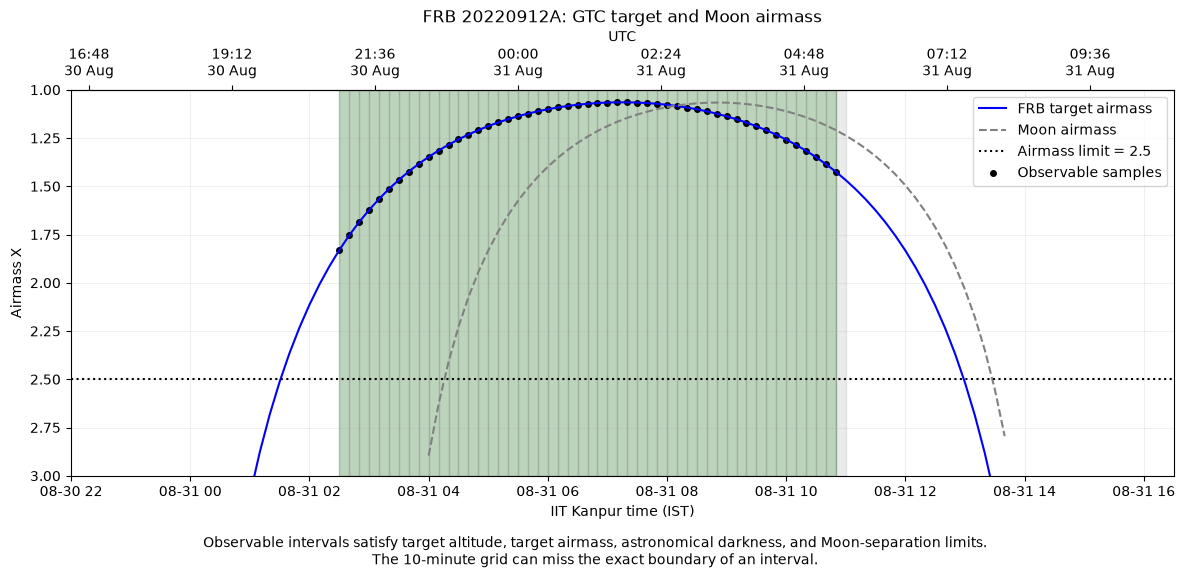

Scientific conclusion: FRB 20220912A is observable only during the intervals where all four constraints pass simultaneously.
Grid limitation: the 10-minute sampling gives boundary times only to approximately the sampling cadence.


In [213]:
def stitch_windows(times, visibility_state):
    visibility_state = np.asarray(visibility_state, dtype=bool)
    if visibility_state.ndim != 1 or len(times) != len(visibility_state):
        raise ValueError("times and visibility_state must be equal one-dimensional arrays.")

    windows = []
    start = None
    for i, visible in enumerate(visibility_state):
        if visible and start is None:
            start = i
        if start is not None and (not visible or i == len(visibility_state) - 1):
            end = i if visible and i == len(visibility_state) - 1 else i - 1
            windows.append((start, end))
            start = None
    return windows

windows = stitch_windows(times, preferred_visibility)
print(f"Number of observable intervals: {len(windows)}")
for start, end in windows:
    window_times = times[start:end + 1]
    window_airmass = target_airmass[start:end + 1]
    midpoint = start + (end - start) // 2
    duration = (window_times[-1] - window_times[0]).to_value(u.hour)
    print(f"UTC: {format_utc(window_times[0])} to {format_utc(window_times[-1])}")
    print(f"IST: {format_iitk(window_times[0])} to {format_iitk(window_times[-1])}")
    print(f"Sample-centre duration: {duration:.3f} h")
    print(f"Best target airmass: {np.nanmin(window_airmass):.6f}")
    print(f"Midpoint Moon label: {moon_label[midpoint]}")

fig, ax = plt.subplots(figsize=(12, 6))
x = times.to_datetime(timezone=IITK_TIMEZONE)
ax.plot(x, target_airmass, color="blue", label="FRB target airmass")
ax.plot(x, moon_airmass, color="gray", linestyle="--", label="Moon airmass")
ax.axhline(MAX_AIRMASS, color="black", linestyle=":", label="Airmass limit = 2.5")

for start, end in windows:
    ax.axvspan(x[start], x[end], color="green", alpha=0.20)
ax.scatter(x[preferred_visibility], target_airmass[preferred_visibility], color="black", s=16, label="Observable samples")

night = sun_altitude <= MAX_SUN_ALTITUDE_DEG
for i in range(len(times) - 1):
    if night[i]:
        ax.axvspan(x[i], x[i + 1], color="black", alpha=0.08)

ax.set_ylim(3, 1)
ax.set_ylabel("Airmass X")
ax.set_xlabel("IIT Kanpur time (IST)")
ax.set_title("FRB 20220912A: GTC target and Moon airmass")
ax.grid(alpha=0.2)
ax.legend()

ax_utc = ax.secondary_xaxis("top")
ax_utc.set_xlabel("UTC")
ax_utc.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M\n%d %b", tz=timezone.utc))
fig.text(0.5, 0.01, "Observable intervals satisfy target altitude, target airmass, astronomical darkness, and Moon-separation limits.\nThe 10-minute grid can miss the exact boundary of an interval.", ha="center")
fig.tight_layout(rect=(0, 0.06, 1, 0.96))
fig.savefig(OUTPUT_DIR / "frb_20220912a_gtc_airmass.png", dpi=180, bbox_inches="tight")
plt.show()

print("Scientific conclusion: FRB 20220912A is observable only during the intervals where all four constraints pass simultaneously.")
print("Grid limitation: the 10-minute sampling gives boundary times only to approximately the sampling cadence.")

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [219]:
q19_start = Time("2026-09-01T00:00:00", scale="utc")
q19_times = q19_start + np.arange(145) * 10 * u.min

q19_altaz = frb_icrs.transform_to(AltAz(obstime=q19_times, location=gtc_location, pressure=0 * u.hPa))
q19_airmass = np.asarray(q19_altaz.secz.to_value(u.dimensionless_unscaled), dtype=float)
q19_airmass[(q19_altaz.alt.to_value(u.deg) <= 0) | (~np.isfinite(q19_airmass)) | (q19_airmass < 1)] = np.nan

with solar_system_ephemeris.set("builtin"):
    q19_sun = get_sun(q19_times).transform_to(AltAz(obstime=q19_times, location=gtc_location, pressure=0 * u.hPa))

q19_visibility = ((q19_altaz.alt.to_value(u.deg) >= 0) &
                  np.isfinite(q19_airmass) &
                  (q19_airmass <= MAX_AIRMASS) &
                  (q19_sun.alt.to_value(u.deg) <= MAX_SUN_ALTITUDE_DEG))

q19_windows = stitch_windows(q19_times, q19_visibility)
q19_total = 0.0
for start, end in q19_windows:
    duration = (q19_times[end] - q19_times[start]).to_value(u.hour)
    q19_total += duration
    print(f"UTC: {format_utc(q19_times[start])} to {format_utc(q19_times[end])}")
    print(f"IST: {format_iitk(q19_times[start])} to {format_iitk(q19_times[end])}")
    print(f"Visible duration: {duration:.3f} h")
print(f"Total visible duration: {q19_total:.3f} h")

UTC: 2026-09-01 00:00:00 UTC to 2026-09-01 05:20:00 UTC
IST: 2026-09-01 05:30:00 IST to 2026-09-01 10:50:00 IST
Visible duration: 5.333 h
UTC: 2026-09-01 21:00:00 UTC to 2026-09-02 00:00:00 UTC
IST: 2026-09-02 02:30:00 IST to 2026-09-02 05:30:00 IST
Visible duration: 3.000 h
Total visible duration: 8.333 h


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [218]:
import imageio.v2 as imageio

Q20_START = Time("2026-08-30T00:00:00", scale="utc")
Q20_DAYS = np.arange(0, 365, 7)
Q20_NSIDE = 8
Q20_NPIX = hp.nside2npix(Q20_NSIDE)
q20_theta, q20_phi = hp.pix2ang(Q20_NSIDE, np.arange(Q20_NPIX))
q20_dec = 90 * u.deg - q20_theta * u.rad
q20_ra = q20_phi * u.rad
q20_sky = SkyCoord(ra=q20_ra, dec=q20_dec, frame="icrs")

frame_dir = OUTPUT_DIR / "q20_frames"
frame_dir.mkdir(parents=True, exist_ok=True)
frame_paths = []

for day in Q20_DAYS:
    date_time = Q20_START + int(day) * u.day
    sample_times = date_time + np.arange(49) * 30 * u.min

    altaz = q20_sky[:, np.newaxis].transform_to(
        AltAz(obstime=sample_times[np.newaxis, :], location=gtc_location, pressure=0 * u.hPa)
    )
    altitude = altaz.alt.to_value(u.deg)
    airmass = np.asarray(altaz.secz.to_value(u.dimensionless_unscaled), dtype=float)
    airmass[(altitude <= 0) | (~np.isfinite(airmass)) | (airmass < 1)] = np.nan

    with solar_system_ephemeris.set("builtin"):
        sun = get_sun(sample_times).transform_to(
            AltAz(obstime=sample_times, location=gtc_location, pressure=0 * u.hPa)
        )
    night = sun.alt.to_value(u.deg) <= MAX_SUN_ALTITUDE_DEG
    visible = (
        (altitude >= 0) &
        np.isfinite(airmass) &
        (airmass <= MAX_AIRMASS) &
        night[np.newaxis, :]
    )
    visibility_hours = visible.sum(axis=1) * 0.5

    values = np.ma.masked_where(visibility_hours == 0, visibility_hours)
    plt.figure(figsize=(10, 5.5))
    hp.mollview(
        values,
        fig=plt.gcf().number,
        title=f"GTC visibility time: {date_time.utc.strftime('%Y-%m-%d')} UTC",
        unit="hours",
        min=0,
        max=12,
        cbar=True,
    )
    hp.graticule()
    frame_path = frame_dir / f"gtc_visibility_{date_time.utc.strftime('%Y%m%d')}.png"
    plt.savefig(frame_path, dpi=120, bbox_inches="tight")
    plt.close()
    frame_paths.append(frame_path)

frames = [imageio.imread(path) for path in frame_paths]
gif_path = OUTPUT_DIR / "gtc_one_year_visibility.gif"
imageio.mimsave(gif_path, frames, duration=0.18, loop=0)

print(f"Frames generated: {len(frame_paths)}")
print(f"GIF: {gif_path}")

Frames generated: 53
GIF: assignment_outputs\gtc_one_year_visibility.gif
The observable region changes through the year because Earth's orbital motion changes the Sun's apparent position and therefore the timing of astronomical night relative to the fixed celestial grid.


Answer: The HEALPix map stores the total number of visible half-hour samples for each sky pixel. Over the year the fixed celestial grid stays fixed, while the Sun's apparent position and the timing of astronomical night change, so the region satisfying the nighttime and airmass constraints shifts.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
